In [1]:
# импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import inspect
import json
import os
import sys
import platform
from sklearn.base import clone

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb
import xgboost as xgb

# **Этап 1. Обзор датасета и EDA**

## **1.1. train.csv**

In [2]:
# выведем первые записи датасета для ознакомления
train = pd.read_csv('./data/train.csv')
train.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


In [3]:
# выведем размер файла
train.shape

(11091, 5)

Файл `train.csv` состоит из 11091 строки и 5 столбцов.

In [4]:
# посчитаем процент пропусков в каждом столбце
for col in train.columns:
  train_missing = np.mean(train[col].isnull())
  print('{} - {}%'.format(col, round(train_missing*100, 2)))

cookie_id - 0.0%
cookie_created_at - 0.0%
window_start_ts - 0.0%
window_end_ts - 0.0%
target - 0.0%


In [5]:
# выведем тип данных в каждом столбце
for col in train.columns:
    print(f'{col} - {train[col].dtype}')

cookie_id - object
cookie_created_at - object
window_start_ts - object
window_end_ts - object
target - int64


| Переменная | Описание | Тип | Пропуски |
| --- | --- | ---: | ---: |
| cookie_id | Идентификатор куки | object | 0% |
| cookie_created_at | Время первого появления куки | object | 0% |
| window_start_ts | Начало окна наблюдения | object | 0% |
| window_end_ts | Окончание окна наблюдения | object | 0% |
| target | Целевая переменная | int | 0% |

In [6]:
# преобразуем временные колонки в datetime
train['cookie_created_at'] = pd.to_datetime(train['cookie_created_at'])
train['window_start_ts'] = pd.to_datetime(train['window_start_ts'])
train['window_end_ts'] = pd.to_datetime(train['window_end_ts'])

# проверим, что преобразование object в datetime произвелось успешно
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11091 entries, 0 to 11090
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cookie_id          11091 non-null  object        
 1   cookie_created_at  11091 non-null  datetime64[ns]
 2   window_start_ts    11091 non-null  datetime64[ns]
 3   window_end_ts      11091 non-null  datetime64[ns]
 4   target             11091 non-null  int64         
dtypes: datetime64[ns](3), int64(1), object(1)
memory usage: 433.4+ KB


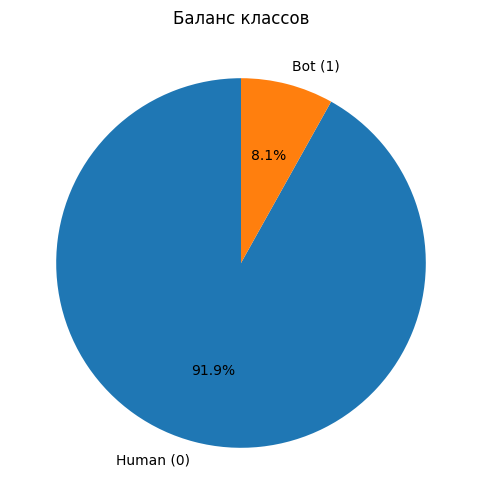

target
0    10192
1      899
Name: count, dtype: int64


In [7]:
# проверим целевую переменную на дисбаланс классов
counts = train['target'].value_counts().sort_index()

# построим круговую диаграмму с долями
plt.figure(figsize=(6, 6))
plt.pie(
    counts.values,
    labels=['Human (0)', 'Bot (1)'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Баланс классов')
plt.show()

# посчитаем в абсолютных значениях
print(train['target'].value_counts())

В датасете присутствует дисбаланс классов. Человек действовал в 10192 случаях, что составляет 91,9%. Бот детектирован в 899 случаях, что составляет 8,1%.

                                  min                 max  span_days
cookie_created_at 2025-01-22 17:09:47 2026-04-18 22:45:04        451
window_start_ts   2026-04-06 00:00:00 2026-04-19 00:00:00         13
window_end_ts     2026-04-07 00:00:00 2026-04-20 00:00:00         13


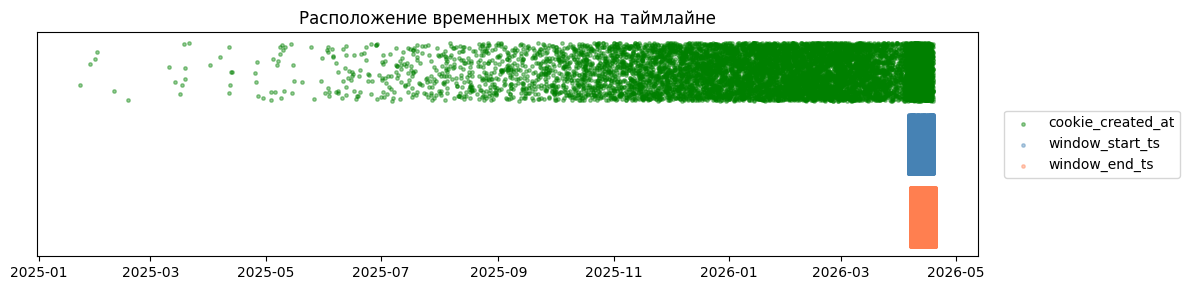

In [8]:
# построим сводную таблицу диапазонов
ranges = pd.DataFrame({
    # найдем минимальную дату начала наблюдения
    'min': [train['cookie_created_at'].min(),
            train['window_start_ts'].min(),
            train['window_end_ts'].min()],
    # найдем максимальную дату окончания наблюдения
    'max': [train['cookie_created_at'].max(),
            train['window_start_ts'].max(),
            train['window_end_ts'].max()],
}, index=['cookie_created_at', 'window_start_ts', 'window_end_ts'])

# добавим продолжительность наблюдения в днях (округлим до целого)
ranges['span_days'] = ((ranges['max'] - ranges['min']).dt.total_seconds() / 86400).round().astype(int)
print(ranges)

# построим таймлайн: точки по времени создания, старта и конца окна
fig, ax = plt.subplots(figsize=(12, 3))
ax.scatter(train['cookie_created_at'], np.random.uniform(0.6, 1.4, len(train)),
           s=6, alpha=0.4, color='green', label='cookie_created_at')
ax.scatter(train['window_start_ts'], np.random.uniform(-0.4, 0.4, len(train)),
           s=6, alpha=0.4, color='steelblue', label='window_start_ts')
ax.scatter(train['window_end_ts'], np.random.uniform(-1.4, -0.6, len(train)),
           s=6, alpha=0.4, color='coral', label='window_end_ts')
ax.set_yticks([])
ax.set_title('Расположение временных меток на таймлайне')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

*   Временные метки `window_start_ts` и `window_end_ts` занимают узкий интервал в 13 дней, тогда как `cookie_created_at` распределена на 451 день. Это указывает на то, чт оокна наблюдения формировались централизованно вограниченном промежутке, в сами куки имеют существенно более длинную историю существования до начала наблюдения.
*   Признаки `window_start_ts` и `window_end_ts` в исходном виде малопригодны для модели, так как их вариативность ограничена 13-дневным интервалом, а внутри окна они, вероятно, близки к константе. Их основная роль - служить фильтром для отбора событий при построении поведенческих признаков.
*   Признак `cookie_created_at` является информативной меткой с широким разбросом. Целесообразно построить производный признак - возраст куки на момент начала окна (`window_start_ts` - `cookie_created_at`). Ранее наблюдаемая асимметрия распределения указывает на то, что этот признак может обладать разделяющей способностью между классами.

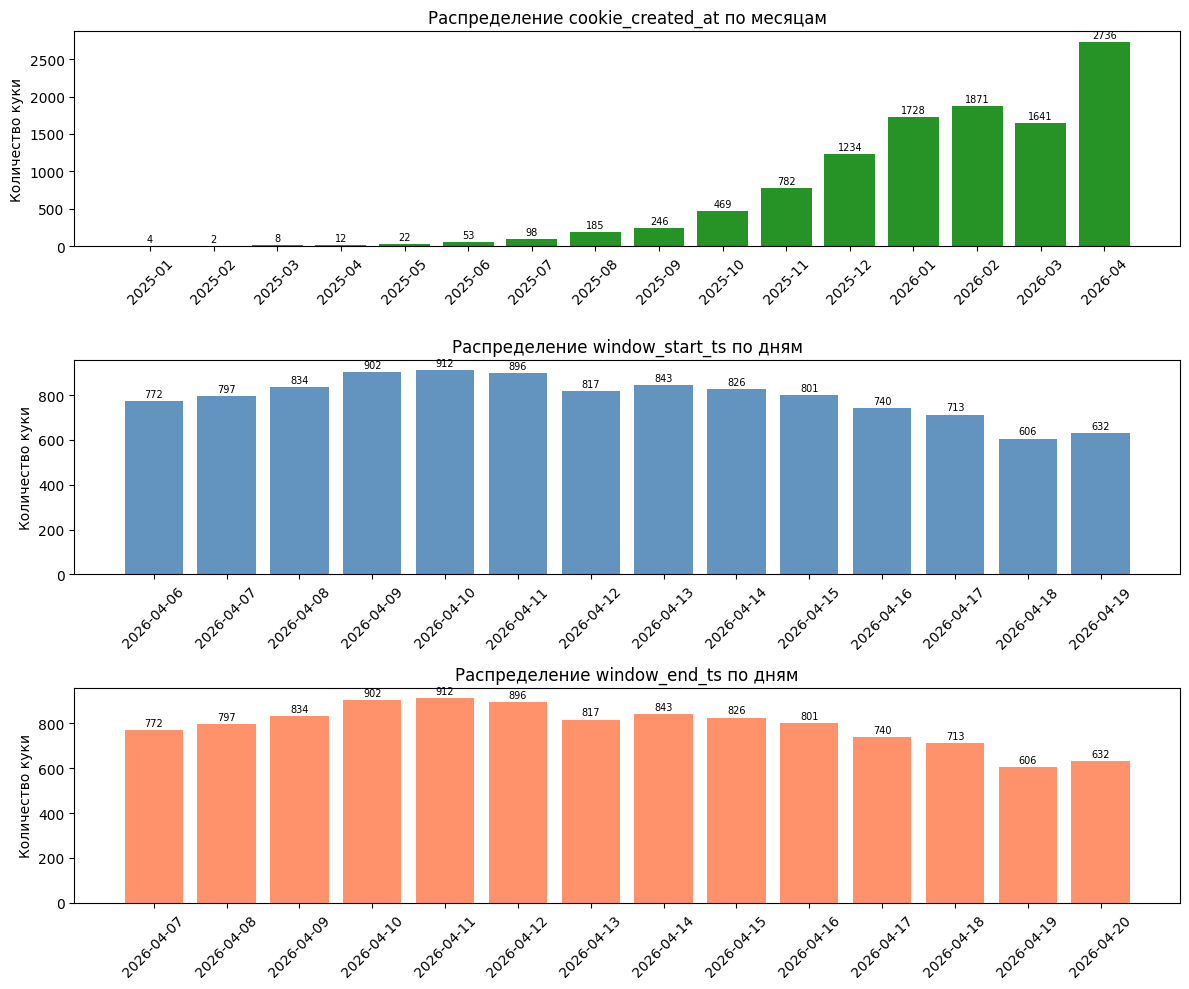

In [9]:
# посмотрим на распределения дат
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# построим для cookie_created_at (по месяцам)
months = train['cookie_created_at'].dt.to_period('M')
counts = months.value_counts().sort_index()

bars = axes[0].bar(counts.index.astype(str), counts.values, color='green', alpha=0.85)
axes[0].set_title('Распределение cookie_created_at по месяцам')
axes[0].set_ylabel('Количество куки')
axes[0].tick_params(axis='x', rotation=45)

for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(counts.values) * 0.01,
                 str(val),
                 ha='center', va='bottom', fontsize=7)

# построим для window_start_ts и window_end_ts (по дням)
for ax, col, color in zip(axes[1:],
                          ['window_start_ts', 'window_end_ts'],
                          ['steelblue', 'coral']):
    days = train[col].dt.to_period('D')
    counts = days.value_counts().sort_index()

    bars = ax.bar(counts.index.astype(str), counts.values, color=color, alpha=0.85)
    ax.set_title(f'Распределение {col} по дням')
    ax.set_ylabel('Количество куки')
    ax.tick_params(axis='x', rotation=45)

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(counts.values) * 0.01,
                str(val),
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

*   `cookie_created_at`: резкий рост к апрелю 2026 - почти 40% куки созданы прямо перед окном. Возраст куки - сильный будущий признак.
*   `window_start_ts` и `window_end_ts`: одинаковые распределения со сдвигом ровно на 1 день - окно у всех ровно 24 часа.
*   Окно наблюдения - 14 дней (06.04–20.04.2026), с плавным спадом к концу.


In [10]:
# считаем долю ботов и объём куки по дням старта окна
train['window_day'] = train['window_start_ts'].dt.floor('D')

daily = (train.groupby('window_day')['target']
         .agg(['mean', 'count'])
         .reset_index())

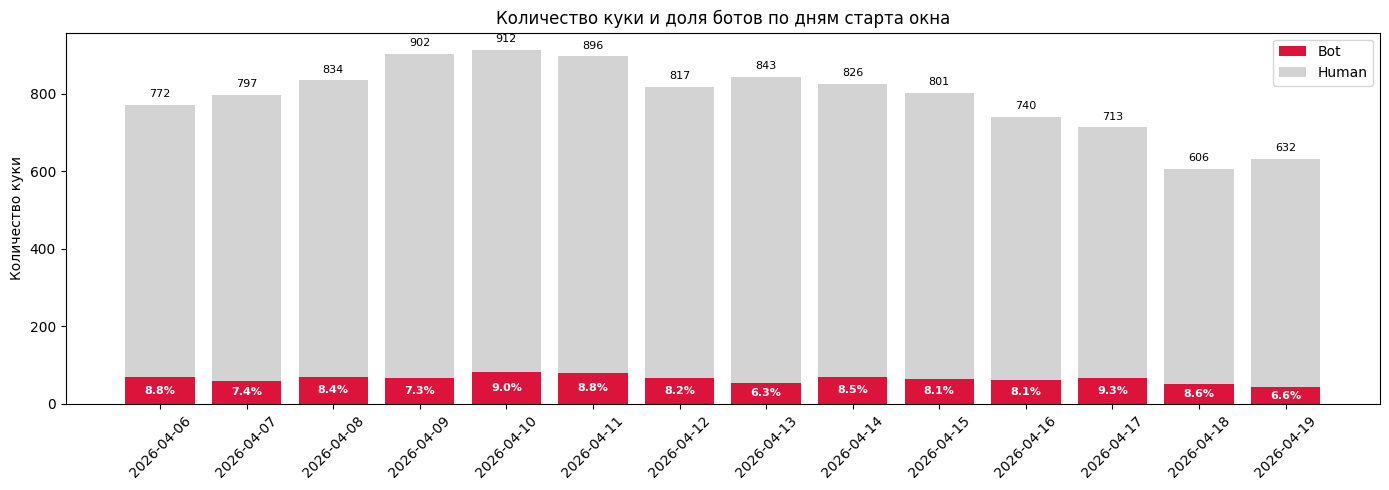

In [11]:
# посчитаем, какой процент ботов был в каждый из наблюдаемых дней
fig, ax = plt.subplots(figsize=(14, 5))

days = daily['window_day'].astype(str)

# абсолютные количества
human_cnt = daily['count'] * (1 - daily['mean'])
bot_cnt   = daily['count'] * daily['mean']

# нижняя часть - боты, верхняя - люди
ax.bar(days, bot_cnt,   color='crimson',    label='Bot')
ax.bar(days, human_cnt, bottom=bot_cnt, color='lightgray', label='Human')

# подписи
for i, (cnt, bot, hum) in enumerate(zip(daily['count'], bot_cnt, human_cnt)):
    # сверху над столбиком - общее количество куки в этот день
    ax.text(i, cnt + 15, f'{int(cnt)}',
            ha='center', va='bottom', fontsize=8, color='black')
    # внутри красной части - процент ботов
    ax.text(i, bot / 2, f'{bot / cnt * 100:.1f}%',
            ha='center', va='center', fontsize=8,
            color='white', fontweight='bold')

ax.set_ylabel('Количество куки')
ax.set_title('Количество куки и доля ботов по дням старта окна')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

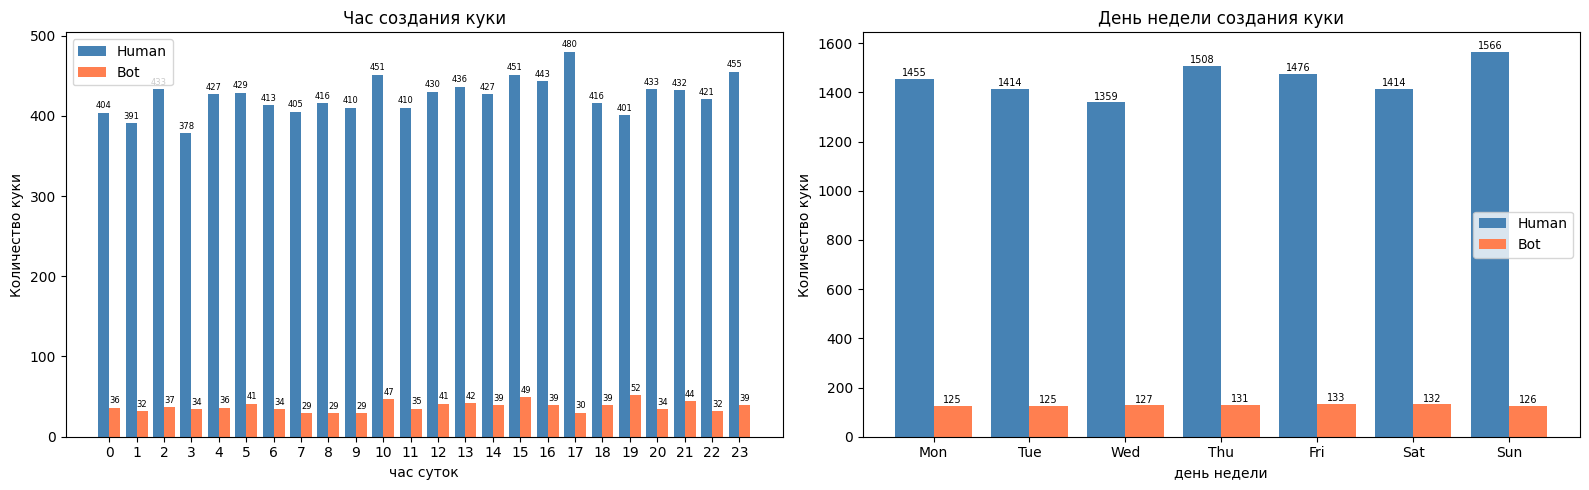

In [12]:
# выделяем час и день недели создания куки
train['created_hour'] = train['cookie_created_at'].dt.hour
train['created_dow']  = train['cookie_created_at'].dt.dayofweek

# построим распределения по дням недели и часам
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

width = 0.4

# посмотрим на часы создания куки
hours = np.arange(24)
human_h = train.loc[train['target'] == 0, 'created_hour'].value_counts().reindex(hours, fill_value=0)
bot_h   = train.loc[train['target'] == 1, 'created_hour'].value_counts().reindex(hours, fill_value=0)

axes[0].bar(hours - width/2, human_h.values, width, color='steelblue', label='Human')
axes[0].bar(hours + width/2, bot_h.values,   width, color='coral',     label='Bot')

for h, val in zip(hours - width/2, human_h.values):
    axes[0].text(h, val + 3, str(int(val)),
                 ha='center', va='bottom', fontsize=6)
for h, val in zip(hours + width/2, bot_h.values):
    axes[0].text(h, val + 3, str(int(val)),
                 ha='center', va='bottom', fontsize=6)

axes[0].set_title('Час создания куки')
axes[0].set_xlabel('час суток')
axes[0].set_ylabel('Количество куки')
axes[0].set_xticks(hours)
axes[0].legend()

# посмотрим на дни недели создания куки
dows = np.arange(7)
human_d = train.loc[train['target'] == 0, 'created_dow'].value_counts().reindex(dows, fill_value=0)
bot_d   = train.loc[train['target'] == 1, 'created_dow'].value_counts().reindex(dows, fill_value=0)

axes[1].bar(dows - width/2, human_d.values, width, color='steelblue', label='Human')
axes[1].bar(dows + width/2, bot_d.values,   width, color='coral',     label='Bot')

for d, val in zip(dows - width/2, human_d.values):
    axes[1].text(d, val + 3, str(int(val)),
                 ha='center', va='bottom', fontsize=7)
for d, val in zip(dows + width/2, bot_d.values):
    axes[1].text(d, val + 3, str(int(val)),
                 ha='center', va='bottom', fontsize=7)

axes[1].set_title('День недели создания куки')
axes[1].set_xlabel('день недели')
axes[1].set_ylabel('Количество куки')
axes[1].set_xticks(dows)
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].legend()

plt.tight_layout()
plt.show()

**Распределение по часу создания куки**
*   Распределение `Human` по часам суток близко к равномерному: значения колеблются в диапазоне 378–480, без выраженных пиков. Небольшой провал наблюдается в утренние часы (3–8), лёгкий рост - днём и вечером (10–17, 22–23).
*   `Bot` распределены схожим образом: 29–52 куки в час, также без ярких экстремумов. Соотношение классов внутри каждого часа стабильное - примерно 1:10 в пользу Human. Это означает, что час создания не является разделяющим признаком — ни по абсолютным числам, ни по относительной доле ботов.

**Распределение по дню недели создания куки**
*   Распределение `Human` по дням недели также почти равномерное: 1359 (среда) - 1566 (воскресенье). `Bot` - от 125 (понедельник, вторник) до 133 (пятница).
*   Разница между максимумом и минимумом - около 15%, что сопоставимо с естественным шумом. Никакого "офисного" или "ночного" паттерна у ботов не наблюдается. День недели как признак также не даёт сигнала.

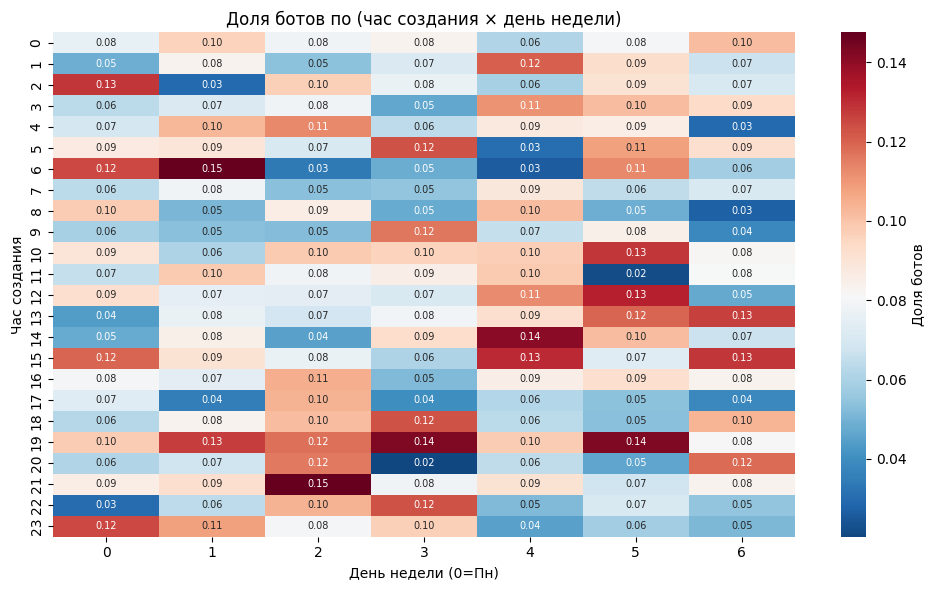

In [13]:
# проверим наличие корреляций между активностью ботов по часам и дням недели
pivot = train.pivot_table(
    index='created_hour',
    columns='created_dow',
    values='target',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap='RdBu_r', center=train['target'].mean(),
            annot=True, fmt='.2f', annot_kws={'size': 7},
            cbar_kws={'label': 'Доля ботов'})
plt.title('Доля ботов по (час создания × день недели)')
plt.xlabel('День недели (0=Пн)')
plt.ylabel('Час создания')
plt.tight_layout()
plt.show()

Тепловая карта не выявляет устойчивых зон концентрации ботов; наблюдаемая картина согласуется с гипотезой случайного распределения. Значения доли ботов по всем 168 ячейкам колеблются в диапазоне 0.02–0.15 при средней ~0.08. Экстремальные значения (0.15 в понедельник 7 утра и субботу 19 вечера, 0.14 в четверг 15 и воскресенье 15 и 20) выглядят как случайные всплески на малых выборках, а не как устойчивая закономерность.

**Выводы по EDA для train.csv**

* **Структура данных.** Выборка содержит 11 091 куку с пятью полями: `cookie_id`, три временные метки и `target`. Дубликатов и пропусков в `train.csv` нет. Боты составляют около 8%, поэтому метрика `Precision@Recall≥70%` чувствительна к ранжированию положительного класса.
* **Временные метки.** Окна наблюдения имеют одинаковую длительность 24 часа. `window_start_ts` и `window_end_ts` используются не как самостоятельные поведенческие признаки, а как границы отбора событий. Поскольку test расположен позже train, основная валидация ниже выполняется по времени.
* **Главный метаданный признак** — `cookie_created_at`. Из него строится `cookie_age_h` — возраст cookie на начало окна наблюдения.
* **Час и день недели создания.** В текущую модель не включаются: устойчивого сигнала в EDA не выявлено.


## **1.2. test.csv**

In [14]:
# выведем первые записи датасета для ознакомления
test = pd.read_csv('./data/test.csv')
test.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21
1,ck_a76ee3b3e3e522fd,2026-01-19 13:42:15,2026-04-20,2026-04-21
2,ck_94c9a4d382689e82,2026-04-19 06:28:37,2026-04-20,2026-04-21
3,ck_8eaf9509ad9462a0,2026-01-19 17:18:06,2026-04-20,2026-04-21
4,ck_9a88a5a989cb5bc6,2025-11-09 17:25:13,2026-04-20,2026-04-21


In [15]:
test.shape

(4909, 4)

Файл `test.csv` состоит из 4909 строк и 4 столбцов.

In [16]:
# посчитаем процент пропусков в каждом столбце
for col in test.columns:
  test_missing = np.mean(test[col].isnull())
  print('{} - {}%'.format(col, round(test_missing*100, 2)))

cookie_id - 0.0%
cookie_created_at - 0.0%
window_start_ts - 0.0%
window_end_ts - 0.0%


In [17]:
# выведем тип данных в каждом столбце
for col in test.columns:
    print(f'{col} - {test[col].dtype}')

cookie_id - object
cookie_created_at - object
window_start_ts - object
window_end_ts - object


| Переменная | Описание | Тип | Пропуски |
| --- | --- | ---: | ---: |
| cookie_id | Идентификатор куки | object | 0% |
| cookie_created_at | Время первого появления куки | object | 0% |
| window_start_ts | Начало окна наблюдения | object | 0% |
| window_end_ts | Окончание окна наблюдения | object | 0% |

In [18]:
# преобразуем временные колонки в datetime
test['cookie_created_at'] = pd.to_datetime(test['cookie_created_at'])
test['window_start_ts'] = pd.to_datetime(test['window_start_ts'])
test['window_end_ts'] = pd.to_datetime(test['window_end_ts'])

# проверим, что преобразование object в datetime произвелось успешно
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4909 entries, 0 to 4908
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cookie_id          4909 non-null   object        
 1   cookie_created_at  4909 non-null   datetime64[ns]
 2   window_start_ts    4909 non-null   datetime64[ns]
 3   window_end_ts      4909 non-null   datetime64[ns]
dtypes: datetime64[ns](3), object(1)
memory usage: 153.5+ KB


                                  min                 max  span_days
cookie_created_at 2025-01-15 16:57:05 2026-04-25 23:00:54        465
window_start_ts   2026-04-20 00:00:00 2026-04-26 00:00:00          6
window_end_ts     2026-04-21 00:00:00 2026-04-27 00:00:00          6


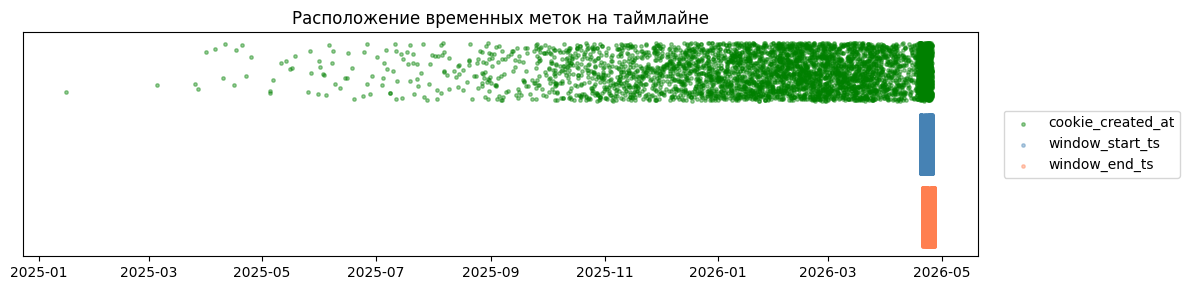

In [19]:
# построим сводную таблицу диапазонов
ranges = pd.DataFrame({
    # найдем минимальную дату начала наблюдения
    'min': [test['cookie_created_at'].min(),
            test['window_start_ts'].min(),
            test['window_end_ts'].min()],
    # найдем максимальную дату окончания наблюдения
    'max': [test['cookie_created_at'].max(),
            test['window_start_ts'].max(),
            test['window_end_ts'].max()],
}, index=['cookie_created_at', 'window_start_ts', 'window_end_ts'])

# добавим продолжительность наблюдения в днях (округлим до целого)
ranges['span_days'] = ((ranges['max'] - ranges['min']).dt.total_seconds() / 86400).round().astype(int)
print(ranges)

# построим таймлайн: точки по времени создания, старта и конца окна
fig, ax = plt.subplots(figsize=(12, 3))
ax.scatter(test['cookie_created_at'], np.random.uniform(0.6, 1.4, len(test)),
           s=6, alpha=0.4, color='green', label='cookie_created_at')
ax.scatter(test['window_start_ts'], np.random.uniform(-0.4, 0.4, len(test)),
           s=6, alpha=0.4, color='steelblue', label='window_start_ts')
ax.scatter(test['window_end_ts'], np.random.uniform(-1.4, -0.6, len(test)),
           s=6, alpha=0.4, color='coral', label='window_end_ts')
ax.set_yticks([])
ax.set_title('Расположение временных меток на таймлайне')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

*   `cookie_created_at` в test охватывает 465 дней, практически совпадая по длине с train (451 день). Диапазон сдвинут вперёд примерно на 7 дней: test заканчивается 25.04.2026, train - 18.04.2026. Начало тоже сдвинуто: 15.01.2025 против 22.01.2025. Это значит, что обе выборки покрывают примерно один и тот же период истории куки, и признак "возраст куки" будет иметь сопоставимое распределение.
*   `window_start_ts` и `window_end_ts` в test занимают 6 дней (20.04–26.04.2026 и 21.04–27.04.2026 соответственно), тогда как в train - 13 дней. То есть окно наблюдения в test короче в два раза, но по-прежнему сдвинуто на 1 день между стартом и концом. Длительность окна у каждой куки остаётся 24 часа.
*   Ключевое отличие: временной интервал test не пересекается с train. Train - окна 06.04–20.04.2026, test - 20.04–27.04.2026. test идёт строго после train.
*   На графике видно, что распределение `cookie_created_at` в test имеет ту же форму, что и в train: редкие точки в начале 2025 года, рост плотности к концу периода, максимум — за 1–2 месяца до окна.

## **1.3. events.csv**

In [20]:
# выведем первые записи датасета для ознакомления
events = pd.read_csv('./data/events.csv')
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [21]:
# выведем размер файла
events.shape

(328905, 14)

Файл `events.csv` состоит из 328905 строк и 14 столбцов.

In [22]:
# посчитаем процент пропусков в каждом столбце
for col in events.columns:
  events_missing = np.mean(events[col].isnull())
  print('{} - {}%'.format(col, round(events_missing*100, 2)))

cookie_id - 0.0%
event_ts - 0.0%
eid - 0.0%
event_name - 0.0%
platform - 0.0%
user_agent - 0.0%
item_id - 34.84%
item_category - 10.01%
item_location - 7.23%
seller_type - 40.7%
search_query - 69.47%
search_page - 69.47%
pointer_x - 67.0%
pointer_y - 67.0%


In [23]:
# выведем тип данных в каждом столбце
for col in events.columns:
    print(f'{col} - {events[col].dtype}')

cookie_id - object
event_ts - object
eid - int64
event_name - object
platform - object
user_agent - object
item_id - float64
item_category - object
item_location - object
seller_type - object
search_query - object
search_page - float64
pointer_x - float64
pointer_y - float64


| Переменная | Описание | Тип | Пропуски |
| --- | --- | ---: | ---: |
| cookie_id | Идентификатор куки | object | 0% |
| event_ts | Время события | object | 0% |
| eid | Код события | int64 | 0% |
| event_name | Название типа события | object | 0% |
| platform | Платформа | object | 0% |
| user_agent | Строка  с параметрами пользователя | object | 0% |
| item_id | Идентификатор объявления | float64 | 34.84% |
| item_category | Категория объявления | object | 10.01% |
| item_location | Локация объявления | object | 7.23% |
| seller_type | Тип продавца | object | 40.7% |
| search_query | Поисковый запрос | object | 69.47% |
| search_page | Номер страницы выдачи | float64 | 69.47% |
| pointer_x | Координаты курсора по X | float64 | 67.0% |
| pointer_y | Координаты курсора по Y | float64 | 67.0% |

In [24]:
# переведем event_ts в datetime
events['event_ts'] = pd.to_datetime(events['event_ts'])

# выведем базовую информацию
print(f"Диапазон: {events['event_ts'].min()} — {events['event_ts'].max()}")
print(f"Всего событий: {len(events):,}")
print(f"Уникальных cookie_id: {events['cookie_id'].nunique():,}")
print(f"Среднее число событий на куку: {len(events) / events['cookie_id'].nunique():.1f}")

Диапазон: 2026-04-06 00:02:57 — 2026-04-26 23:59:50
Всего событий: 328,905
Уникальных cookie_id: 16,000
Среднее число событий на куку: 20.6


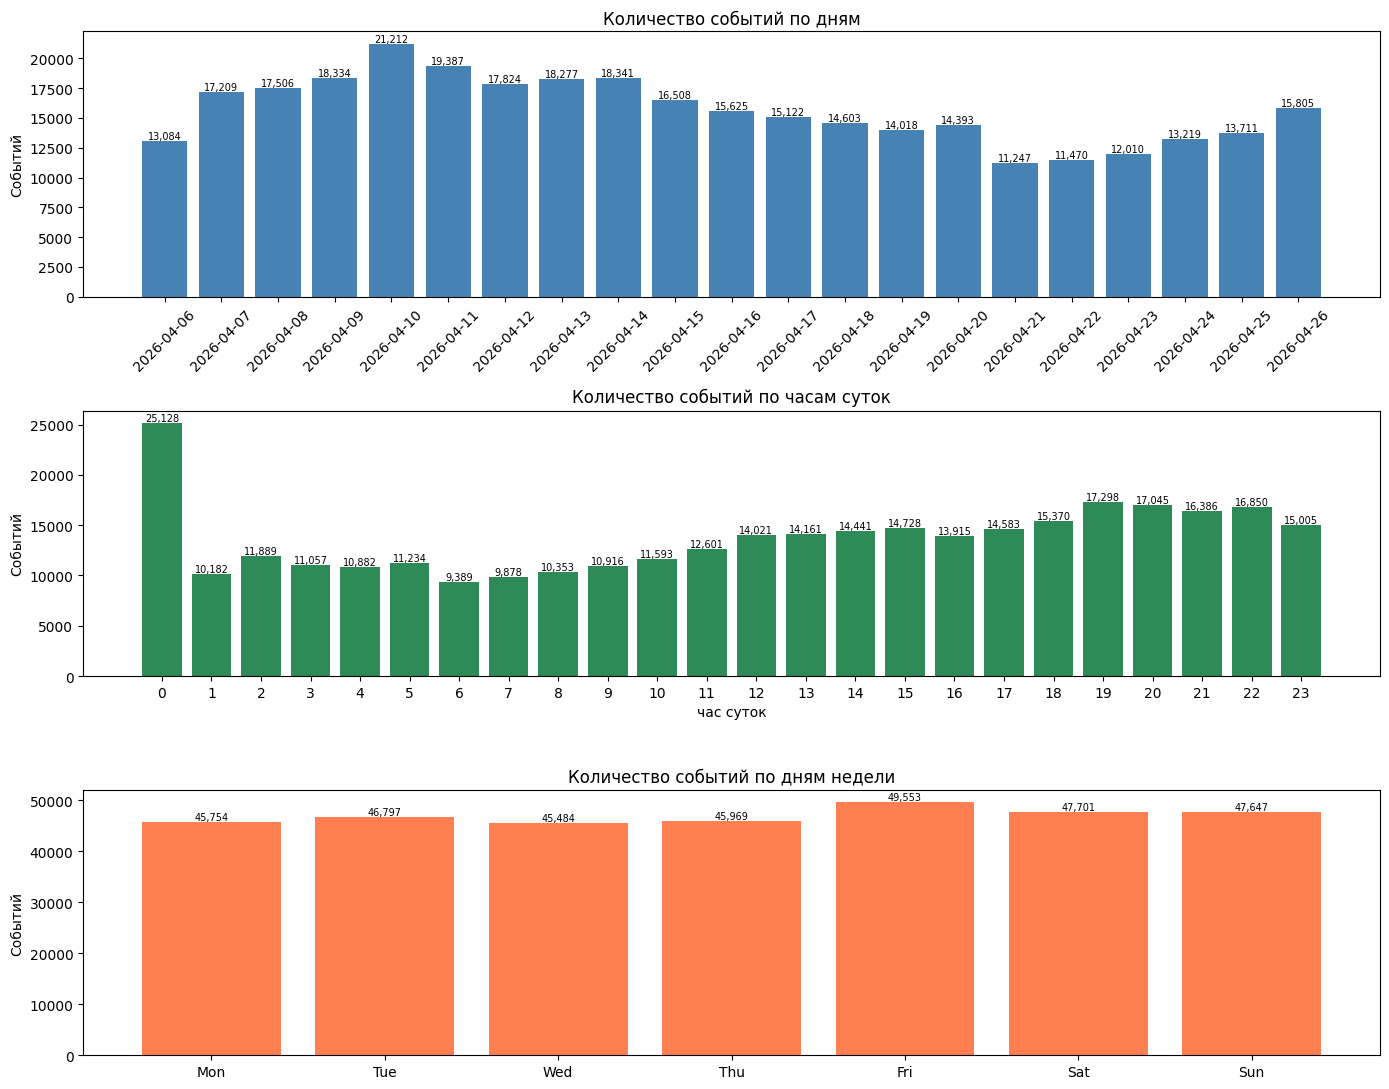

In [25]:
# построим распределения по датам
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# распределения по дням
by_day = events['event_ts'].dt.floor('D').value_counts().sort_index()
bars = axes[0].bar(by_day.index.astype(str), by_day.values, color='steelblue')
axes[0].set_title('Количество событий по дням')
axes[0].set_ylabel('Событий')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, by_day.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f'{val:,}', ha='center', va='bottom', fontsize=7)

# распределения по часам
by_hour = events['event_ts'].dt.hour.value_counts().sort_index()
bars = axes[1].bar(by_hour.index, by_hour.values, color='seagreen')
axes[1].set_title('Количество событий по часам суток')
axes[1].set_xlabel('час суток')
axes[1].set_ylabel('Событий')
axes[1].set_xticks(range(24))
for bar, val in zip(bars, by_hour.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f'{val:,}', ha='center', va='bottom', fontsize=7)

# распределения по дням недели
by_dow = events['event_ts'].dt.dayofweek.value_counts().sort_index()
bars = axes[2].bar(by_dow.index, by_dow.values, color='coral')
axes[2].set_title('Количество событий по дням недели')
axes[2].set_ylabel('Событий')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
for bar, val in zip(bars, by_dow.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f'{val:,}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

**Выводы по распределению событий во времени**

*   **Общие наблюдения**. Диапазон событий - 06.04.2026 00:02:57 - 26.04.2026 23:59:50, то есть ровно 21 день. Всего 328 905 событий для 16 000 уникальных куки. Среднее число событий на куку - 20.6, медиана, скорее всего, ниже (распределение Пуассона с длинным хвостом), но общий порядок говорит, что данных достаточно для поведенческих агрегатов.
*   **Соответствие с train/test**: диапазон 06.04–20.04 совпадает с окнами train, 20.04–26.04 - с test. То есть все события попадают в окна наблюдения, фильтровать по времени ничего не нужно.
*   **По дням**. Объём событий колеблется от 11 247 (21.04) до 21 212 (10.04). Общая форма - плавное снижение с пиком в первой половине периода и небольшим подъёмом в конце. Провалы 21–22 апреля (11k) и подъём 10 апреля (21k) выглядят как естественные колебания активности, а не как аномалия сбора.
*   **По часам**. Отчётливый пик в полночь (25 128 событий) - почти в 2.5 раза больше, чем в любой другой час, кроме вечерних. Далее - плавный рост с 12:00 к вечеру, локальный максимум в 19:00 (17 298), и снижение после 22:00. Минимум - в 6 утра (9 389). Общая форма - типичный суточный профиль человеческой активности, но аномально высокий пик в 00:00 требует проверки.
*   **По дням недели**. Распределение почти равномерное: от 45 484 (среда) до 49 553 (пятница). Разброс - около 8%, что близко к случайному. Никакого "офисного" паттерна (например, резкого спада в выходные) не наблюдается, что логично, так как речь о маркетплейсе, а не о корпоративном трафике.

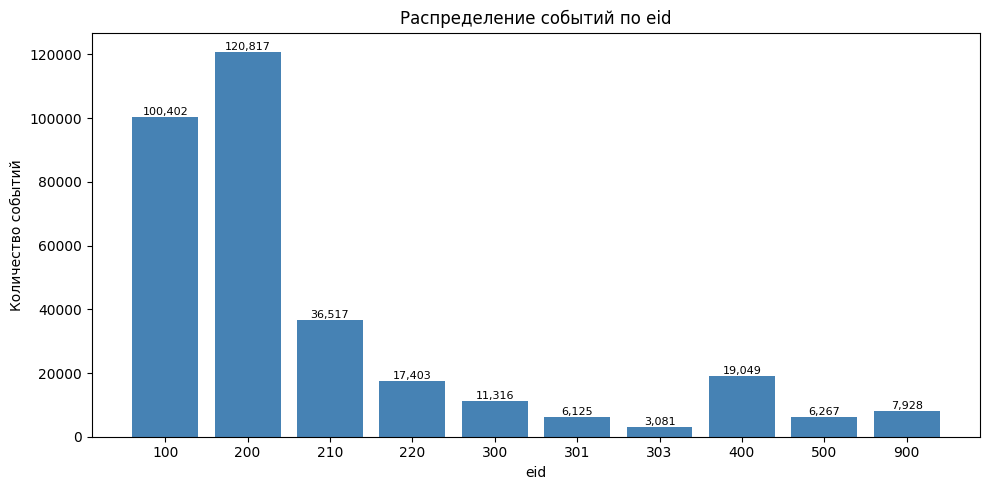

 eid  count  share_%
 100 100402    30.53
 200 120817    36.73
 210  36517    11.10
 220  17403     5.29
 300  11316     3.44
 301   6125     1.86
 303   3081     0.94
 400  19049     5.79
 500   6267     1.91
 900   7928     2.41

Итого: 328,905 событий (100%)


In [26]:
# сделаем визуализацию по eid
eid_counts = events['eid'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(eid_counts.index.astype(str), eid_counts.values, color='steelblue')
ax.set_title('Распределение событий по eid')
ax.set_xlabel('eid')
ax.set_ylabel('Количество событий')

for bar, val in zip(bars, eid_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# выведем таблицу с абсолютными и относительными значениями
eid_table = pd.DataFrame({
    'eid': eid_counts.index,
    'count': eid_counts.values,
    'share_%': (eid_counts.values / len(events) * 100).round(2),
}).reset_index(drop=True)

print(eid_table.to_string(index=False))
print(f"\nИтого: {eid_table['count'].sum():,} событий (100%)")

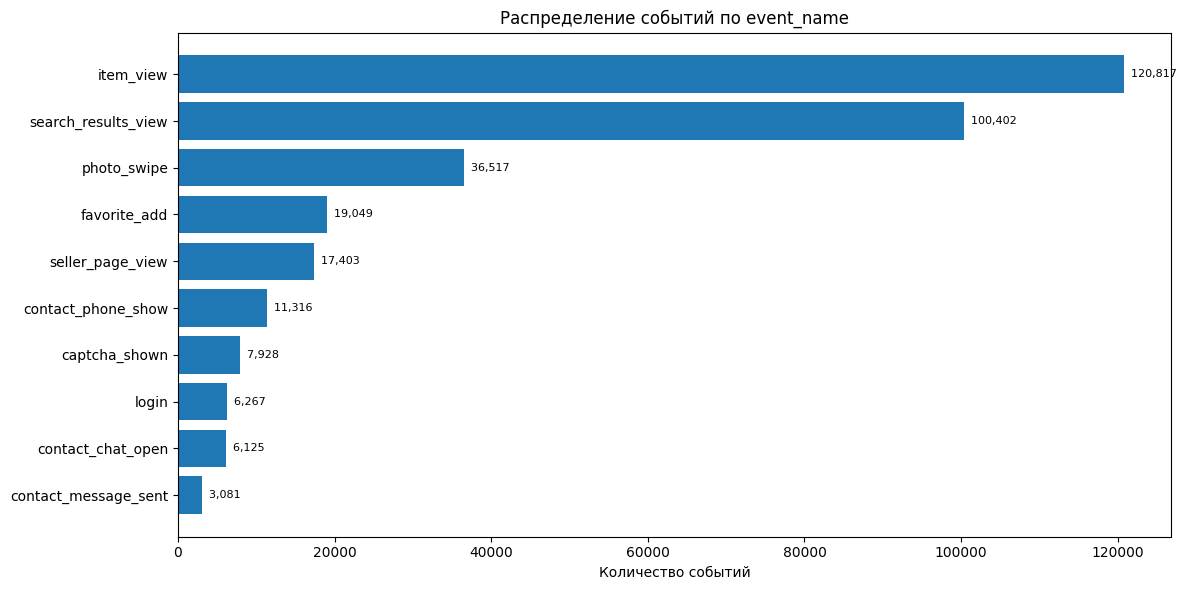

          event_name  count  share_%
           item_view 120817    36.73
 search_results_view 100402    30.53
         photo_swipe  36517    11.10
        favorite_add  19049     5.79
    seller_page_view  17403     5.29
  contact_phone_show  11316     3.44
       captcha_shown   7928     2.41
               login   6267     1.91
   contact_chat_open   6125     1.86
contact_message_sent   3081     0.94

Итого: 328,905 событий (100%)


In [27]:
# сделаем визуализацию по event_name
name_counts = events['event_name'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(name_counts.index[::-1], name_counts.values[::-1])
ax.set_title('Распределение событий по event_name')
ax.set_xlabel('Количество событий')

for bar, val in zip(bars, name_counts.values[::-1]):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
            f'  {val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# выведем таблицу с абсолютными и относительными значениями
name_table = pd.DataFrame({
    'event_name': name_counts.index,
    'count': name_counts.values,
    'share_%': (name_counts.values / len(events) * 100).round(2),
}).reset_index(drop=True)

print(name_table.to_string(index=False))
print(f"\nИтого: {name_table['count'].sum():,} событий (100%)")

Можно заметить, что каждому event_name соответствует код eid. Сделаем соответствие между ними.

In [28]:
# собираем таблицу соответствия eid <-> event_name <-> count <-> share
mapping = (events.groupby(['eid', 'event_name'])
                 .size()
                 .reset_index(name='count')
                 .sort_values('eid')
                 .reset_index(drop=True))
mapping['share_%'] = (mapping['count'] / len(events) * 100).round(2)
print(mapping.to_string(index=False))

 eid           event_name  count  share_%
 100  search_results_view 100402    30.53
 200            item_view 120817    36.73
 210          photo_swipe  36517    11.10
 220     seller_page_view  17403     5.29
 300   contact_phone_show  11316     3.44
 301    contact_chat_open   6125     1.86
 303 contact_message_sent   3081     0.94
 400         favorite_add  19049     5.79
 500                login   6267     1.91
 900        captcha_shown   7928     2.41


В выборке представлено 10 типов событий, между `eid` и `event_name` установлено взаимно однозначное соответствие - для модели достаточно одной колонки (`eid`), вторую можно не использовать.

Распределение крайне неравномерное.

**Навигационные события** доминируют: `item_view` (36.73%) и `search_results_view` (30.53%) вместе дают 67% всех событий, а вся группа навигации (`search_results_view`, `item_view`, `photo_swipe`, `seller_page_view`) - 83.6%.

**Вовлекающие события** (`favorite_add`, `contact_phone_show`, `contact_chat_open`, `contact_message_sent`) занимают 12.0%. Несмотря на меньшую долю, они несут больше сигнала: контактные действия и добавления в избранное - типично человеческие паттерны, и у ботов их доля обычно заметно ниже.

**Редкие, но потенциально сильные признаки:**
* `captcha_shown` (2.41%) - боты чаще попадают на капчу, это один из лучших кандидатов в признаки;
* `login` (1.91%) - боты редко логинятся, а если логинятся, это может быть характерный паттерн;
* `contact_message_sent` (0.94%) - самое редкое событие, но именно такие "хвосты" часто дают максимальный разделяющий эффект.

In [29]:
# приводим platform к нижнему регистру и убираем пробелы, если они есть
events['platform'] = events['platform'].str.lower().str.strip()

# считаем количество и доли
platform_counts = events['platform'].value_counts(dropna=False)

platform_table = pd.DataFrame({
    'platform': platform_counts.index,
    'count': platform_counts.values,
    'share_%': (platform_counts.values / len(events) * 100).round(2),
}).reset_index(drop=True)

print(platform_table.to_string(index=False))
print(f"\nИтого: {platform_table['count'].sum():,} событий (100%)")

platform  count  share_%
     web 138792    42.20
 android 126875    38.57
 desktop  46866    14.25
     ios  12269     3.73
  iphone   4103     1.25

Итого: 328,905 событий (100%)


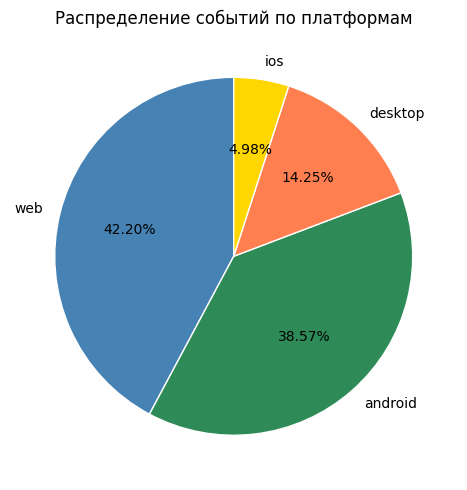

platform  count  share_%
     web 138792    42.20
 android 126875    38.57
 desktop  46866    14.25
     ios  16372     4.98

Итого: 328,905 событий (100%)


In [30]:
# объединяем iphone с ios
events['platform'] = events['platform'].replace({'iphone': 'ios'})

# пересчитываем распределение
platform_counts = events['platform'].value_counts()

platform_table = pd.DataFrame({
    'platform': platform_counts.index,
    'count': platform_counts.values,
    'share_%': (platform_counts.values / len(events) * 100).round(2),
}).reset_index(drop=True)

# делаем визуализацию
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    platform_table['count'],
    labels=platform_table['platform'],
    autopct='%1.2f%%',
    startangle=90,
    colors=['steelblue', 'seagreen', 'coral', 'gold', 'mediumpurple'],
    wedgeprops={'edgecolor': 'white'}
)
ax.set_title('Распределение событий по платформам')
plt.tight_layout()
plt.show()

# выводим таблицу
print(platform_table.to_string(index=False))
print(f"\nИтого: {platform_table['count'].sum():,} событий (100%)")

In [31]:
# выведем кол-во уникальных событий
print(f"Всего событий: {len(events):,}")
print(f"Уникальных user_agent: {events['user_agent'].nunique():,}")

# выведем самые популярные user_agent (топ-10)
print("\nТоп-10 user_agent:")
top_ua = events['user_agent'].value_counts().head(10)
for ua, cnt in top_ua.items():
    print(f"{cnt:>7,}  {ua[:120]}{'...' if len(ua) > 120 else ''}")

Всего событий: 328,905
Уникальных user_agent: 148

Топ-10 user_agent:
  3,737  Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 YaBrowser/23.11.0.0 Sa...
  3,670  Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:119.0) Gecko/20100101 Firefox/119.0
  3,664  Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 YaBrowser/23.9.0.0 Saf...
  3,640  Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 YaBrowser/23.0.0.0 Saf...
  3,558  Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 YaBrowser/23.3.0.0 Saf...
  3,481  Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36
  3,470  Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36
  3,462  Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 

Добавим флаг автоматизации:

*   `ua_is_headless` - используется Headless-браузер, запущенный без окна (используется парсерами, например, Selenium, Puppeteer, Playwright).
*   `ua_is_bot_lib` - используются готовые библиотеки для HTTP-запросов (python-requests, curl, wget, okhttp, aiohttp) или фреймворки для парсинга (scrapy, selenium, playwright, puppeteer, phantomjs).


In [32]:
ua = events['user_agent']

# флаги автоматизации
events['ua_is_headless']  = ua.str.contains('HeadlessChrome', case=False, na=False).astype(int)
events['ua_is_bot_lib']   = ua.str.contains(r'python-requests|curl|wget|Go-http|okhttp|java|phantomjs|selenium|playwright|puppeteer|scrapy|aiohttp',
                                            case=False, regex=True, na=False).astype(int)

print(f"  HeadlessChrome:   {events['ua_is_headless'].sum():>7,}  ({events['ua_is_headless'].mean()*100:.2f}%)")
print(f"  Известные библиотеки:  {events['ua_is_bot_lib'].sum():>7,}  ({events['ua_is_bot_lib'].mean()*100:.2f}%)")

  HeadlessChrome:    12,447  (3.78%)
  Известные библиотеки:   53,828  (16.37%)


In [33]:
# определяем операционные системы
def parse_os(s):
    if pd.isna(s):
        return 'unknown'
    s_lower = s.lower()
    if 'windows nt 10'   in s_lower: return 'Windows 10'
    if 'windows nt 6.3'  in s_lower: return 'Windows 8.1'
    if 'windows nt 6.1'  in s_lower: return 'Windows 7'
    if 'windows'         in s_lower: return 'Windows other'
    if 'mac os x'        in s_lower: return 'macOS'
    if 'android'         in s_lower: return 'Android'
    if 'iphone'          in s_lower: return 'iOS'
    if 'ipad'            in s_lower: return 'iPadOS'
    if 'linux'           in s_lower: return 'Linux'
    return 'other'

events['ua_os'] = events['user_agent'].apply(parse_os)
print("\nОперационные системы:")
print(events['ua_os'].value_counts())


Операционные системы:
ua_os
Android       126875
Windows 10    123850
macOS          47595
Linux          12447
iOS            11070
other           7068
Name: count, dtype: int64


In [34]:
# определяем браузер
def parse_browser(s):
    if pd.isna(s):
        return 'unknown'
    s_lower = s.lower()
    if 'yabrowser'  in s_lower: return 'Yandex'
    if 'edg/'       in s_lower: return 'Edge'
    if 'opr/'       in s_lower or 'opera' in s_lower: return 'Opera'
    if 'firefox'    in s_lower: return 'Firefox'
    if 'headlesschrome' in s_lower: return 'HeadlessChrome'
    if 'chrome'     in s_lower: return 'Chrome'
    if 'safari'     in s_lower: return 'Safari'
    return 'other'

events['ua_browser'] = events['user_agent'].apply(parse_browser)
print("\nБраузеры:")
print(events['ua_browser'].value_counts())


Браузеры:
ua_browser
Chrome            161720
other              67381
Firefox            43727
Yandex             38328
HeadlessChrome     12447
Safari              5302
Name: count, dtype: int64


In [35]:
# определяем тип устройства
def parse_device(s):
    if pd.isna(s):
        return 'unknown'
    s_lower = s.lower()
    if 'mobile'  in s_lower or 'iphone' in s_lower or 'android' in s_lower: return 'mobile'
    if 'tablet'  in s_lower or 'ipad'   in s_lower: return 'tablet'
    return 'desktop'

events['ua_device'] = events['user_agent'].apply(parse_device)
print("\nТипы устройств:")
print(events['ua_device'].value_counts())


Типы устройств:
ua_device
desktop    185658
mobile     143247
Name: count, dtype: int64


Категории объявлений:
item_category
avtomobili           20822
mebel                20541
bytovaya_tehnika     20161
hobbi                20020
elektronika          20002
uslugi               19869
odezhda              19846
kvartiry_arenda      19713
kvartiry_prodazha    19709
noutbuki             19583
detskie_tovary       19441
rabota               19387
telefony             19349
zhivotnye            19109
zapchasti            18433
Name: count, dtype: int64


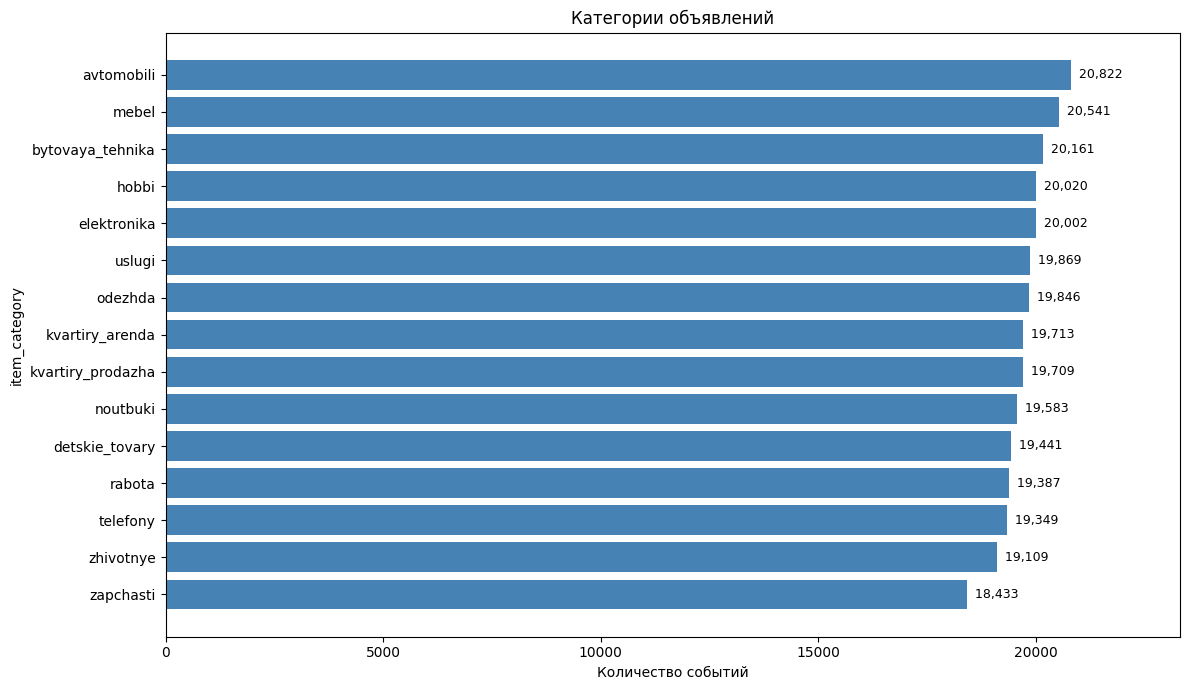

In [36]:
# выведем категории объявлений
print("Категории объявлений:")
print(events['item_category'].value_counts())

# построим гистограмму
top_cat = events['item_category'].value_counts()

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_cat.index[::-1], top_cat.values[::-1], color='steelblue')

ax.set_title('Категории объявлений')
ax.set_xlabel('Количество событий')
ax.set_ylabel('item_category')

# добавим подписи значений
for bar, val in zip(bars, top_cat.values[::-1]):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
            f'  {val:,}', va='center', fontsize=9)

ax.set_xlim(0, top_cat.max() * 1.12)
plt.tight_layout()
plt.show()

Распределение почти равномерное: 15 категорий в диапазоне 18 433–20 822 событий, разброс ~13%. Явного лидера нет.

Топ-20 локаций:
item_location
sankt-peterburg    39221
novosibirsk        37989
moskva             37964
ekaterinburg       37281
ryazan              4627
izhevsk             4576
barnaul             4559
astrahan            4511
ufa                 4481
vladivostok         4469
krasnodar           4431
kirov               4373
tyumen              4368
rostov-na-donu      4368
ulyanovsk           4351
volgograd           4339
kazan               4325
kemerovo            4316
omsk                4314
voronezh            4288
Name: count, dtype: int64


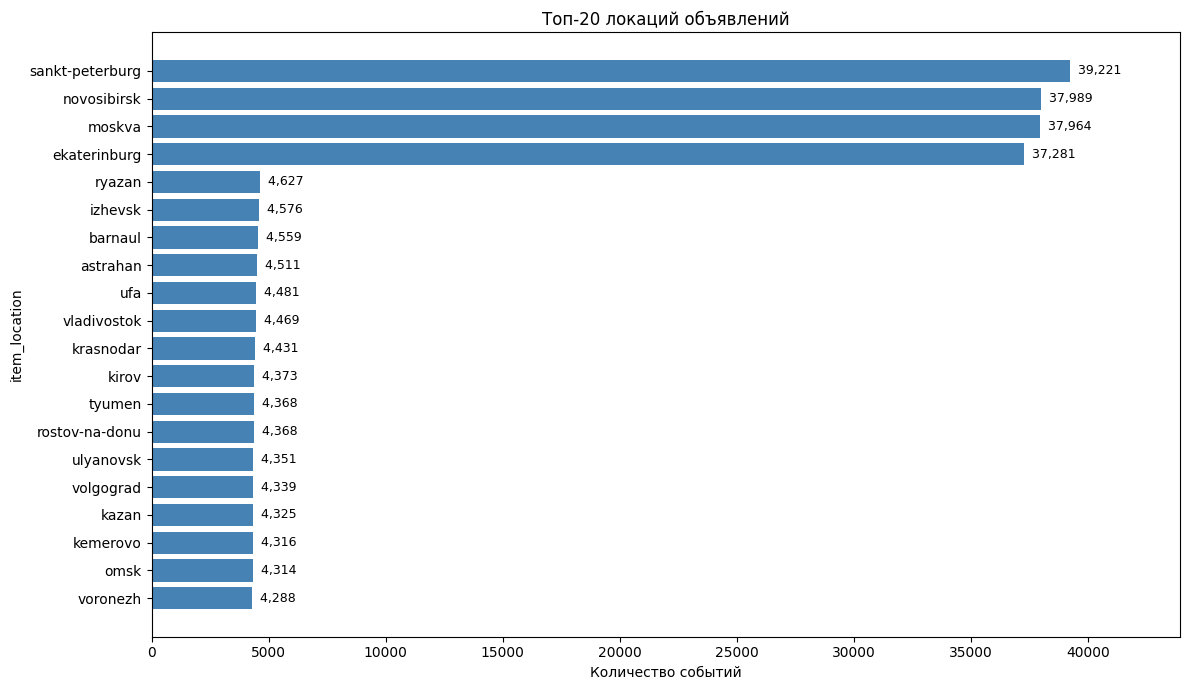

In [37]:
# выведем топ-20 локаций
print("Топ-20 локаций:")
print(events['item_location'].value_counts().head(20))

# построим гистограмму
top_cat = events['item_location'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_cat.index[::-1], top_cat.values[::-1], color='steelblue')

ax.set_title('Топ-20 локаций объявлений')
ax.set_xlabel('Количество событий')
ax.set_ylabel('item_location')

# добавим подписи значений
for bar, val in zip(bars, top_cat.values[::-1]):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
            f'  {val:,}', va='center', fontsize=9)

ax.set_xlim(0, top_cat.max() * 1.12)
plt.tight_layout()
plt.show()


* Города-миллионники с аномально высокой активностью: Санкт-Петербург - 39 221, Новосибирск - 37 989, Москва - 37 964, Екатеринбург - 37 281.
* Четыре локации дают ~152 000 событий, что составляет почти половину всей выборки (около 46%). При этом Москва и Санкт-Петербург - ожидаемо крупнейшие рынки, но Новосибирск и Екатеринбург сейчас находятся на одном уровне с ними.
* Остальные города: Рязань, Ижевск, Барнаул, Астрахань, Уфа, Владивосток, Краснодар, Киров, Тюмень, Ростов-на-Дону, Ульяновск, Волгоград, Казань, Кемерово, Омск, Воронеж - все в диапазоне 4 288–4 627 событий, практически равномерно.


seller_type:
seller_type
NaN        133853
private    112631
pro         82421
Name: count, dtype: int64


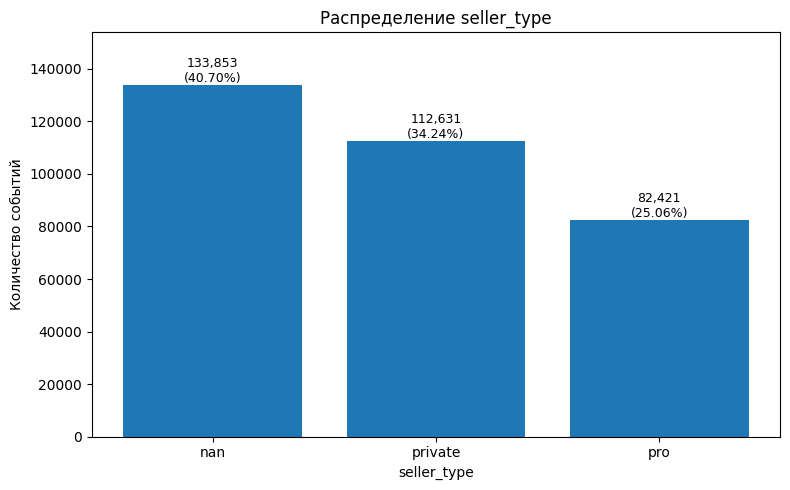

In [38]:
# выведем тип продавца
print("\nseller_type:")
print(events['seller_type'].value_counts(dropna=False))

# сделаем визуализацию
st_counts = events['seller_type'].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(8, 5))
labels = st_counts.index.astype(str)
bars = ax.bar(labels, st_counts.values)

ax.set_title('Распределение seller_type')
ax.set_xlabel('seller_type')
ax.set_ylabel('Количество событий')

for bar, val in zip(bars, st_counts.values):
    pct = val / len(events) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:,}\n({pct:.2f}%)', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, st_counts.max() * 1.15)
plt.tight_layout()
plt.show()

Распределение относительно сбалансированное, без резких перекосов:
* `nan` - 133 853 (40.70%) - события без привязки к продавцу (поиск, логин, капча, просмотр фото и т. п.).
* `private` - 112 631 (34.24%) - частные продавцы.
* `pro` - 82 421 (25.06%) - профессиональные продавцы (магазины, компании).

In [39]:
# берём заполненные значения search_query
sq = events['search_query'].dropna()

# смотрим на поисковые запросы
q_counts = sq.value_counts()

q_table = pd.DataFrame({
    'search_query': q_counts.index,
    'count': q_counts.values,
    'share_%': (q_counts.values / len(sq) * 100).round(3),
}).reset_index(drop=True)

print(f"Всего уникальных запросов: {len(q_table)}")
print()
print(q_table.to_string(index=False))
print(f"\nИтого: {q_table['count'].sum():,} событий (100%)")

Всего уникальных запросов: 120

            search_query  count  share_%
            toyota camry    919    0.915
              кофемашина    919    0.915
                 клининг    918    0.914
           renault logan    916    0.912
            kia rio 2019    908    0.904
    посудомоечная машина    904    0.900
             вторичка 2к    904    0.900
               шкаф купе    897    0.893
            телевизор 55    897    0.893
         стол письменный    897    0.893
   квартира без комиссии    895    0.891
         volkswagen polo    894    0.890
                  коньки    892    0.888
            джинсы levis    891    0.887
           skoda octavia    891    0.887
         работа курьером    890    0.886
             новостройка    888    0.884
    xiaomi redmi note 12    886    0.882
             samsung a54    884    0.880
                 пуховик    881    0.877
          пальто женское    880    0.876
         самокат детский    880    0.876
      квартира посуточно 

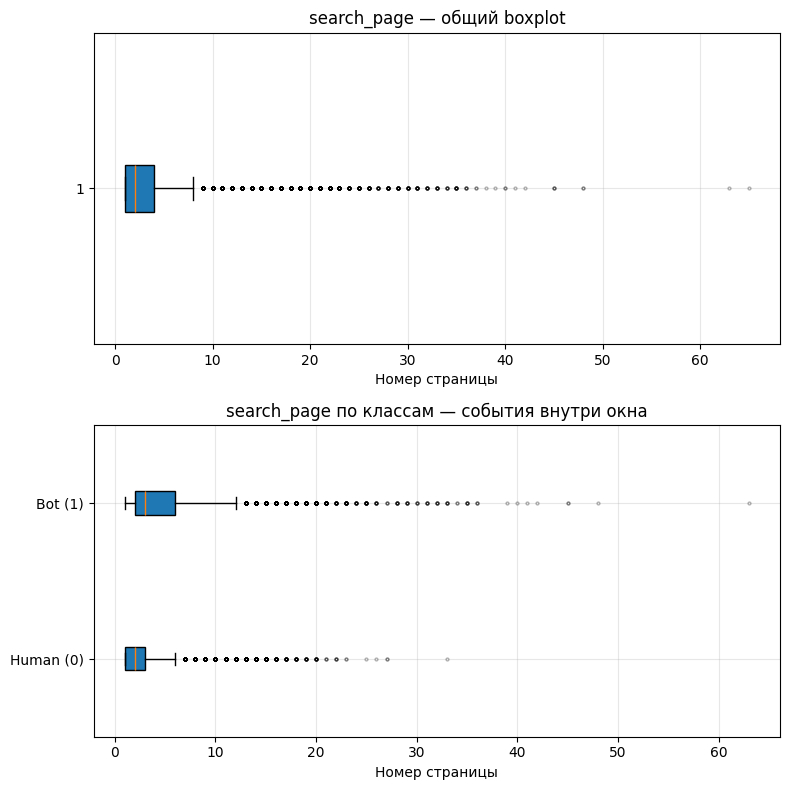

In [40]:
# для сравнительного EDA используем только события внутри индивидуального окна наблюдения
train_windows = train[['cookie_id', 'target', 'window_start_ts', 'window_end_ts']]
events_with_target = events.merge(train_windows, on='cookie_id', how='inner')
events_with_target = events_with_target[
    (events_with_target['event_ts'] >= events_with_target['window_start_ts']) &
    (events_with_target['event_ts'] < events_with_target['window_end_ts'])
].copy()

sub_t = events_with_target.dropna(subset=['search_page'])
sp_human = sub_t.loc[sub_t['target'] == 0, 'search_page'].values
sp_bot   = sub_t.loc[sub_t['target'] == 1, 'search_page'].values

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
bp1 = axes[0].boxplot(events['search_page'].dropna(), vert=False, patch_artist=True,
                      flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
axes[0].set_title('search_page — общий boxplot')
axes[0].set_xlabel('Номер страницы')
axes[0].grid(True, alpha=0.3)

bp2 = axes[1].boxplot([sp_human, sp_bot], vert=False, patch_artist=True,
                      flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
axes[1].set_yticklabels(['Human (0)', 'Bot (1)'])
axes[1].set_title('search_page по классам — события внутри окна')
axes[1].set_xlabel('Номер страницы')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Общий boxplot: медиана - 1, верхний квартиль - 2, "усы" короткие (до ~9). Основная масса событий сосредоточена на страницах 1–2. Выбросы тянутся до 65, но их мало - единичные события на глубоких страницах.

Разделение по классам:
* `Human`: ящик компактный (между 1 и 2), медиана - 1, "усы" доходят до ~8. Выбросы редкие, до ~35.
* `Bot`: ящик заметно растянут - верхний квартиль выше, медиана сдвинута вправо, "усы" доходят до ~18–20. Хвост выбросов плотный и тянется до 65.

Боты листают выдачу глубже, чем люди.

In [41]:
# базовая статистика
for col in ['pointer_x', 'pointer_y']:
    p = events[col].dropna()
    print(f"\n--- {col} ---")
    print(f"Заполнено: {len(p):,} ({len(p)/len(events)*100:.2f}%)")
    print(f"Уникальных значений: {p.nunique():,}")
    print(p.describe(percentiles=[.01, .25, .5, .75, .99]).round(2))
    print(f"Отрицательных: {(p < 0).sum():,}")
    print(f"Ровно 0:       {(p == 0).sum():,}")
    print(f"> 2000:        {(p > 2000).sum():,}")
    print(f"> 4000:        {(p > 4000).sum():,}")


--- pointer_x ---
Заполнено: 108,540 (33.00%)
Уникальных значений: 1,921
count    108540.00
mean        913.28
std         538.45
min           0.00
1%           11.00
25%         458.00
50%         883.00
75%        1359.00
99%        1897.00
max        1920.00
Name: pointer_x, dtype: float64
Отрицательных: 0
Ровно 0:       522
> 2000:        0
> 4000:        0

--- pointer_y ---
Заполнено: 108,540 (33.00%)
Уникальных значений: 1,081
count    108540.00
mean        535.56
std         303.86
min           0.00
1%            5.00
25%         282.00
50%         533.00
75%         789.00
99%        1071.00
max        1080.00
Name: pointer_y, dtype: float64
Отрицательных: 0
Ровно 0:       706
> 2000:        0
> 4000:        0


Координата (0, 0) - это техническая подпись автоматизации: клиент не передаёт реальные координаты курсора, а логирует нули. Это бывает, когда парсер работает через низкоуровневые HTTP-запросы (не эмулирует мышь) или когда разработчик бота намеренно зануляет координаты.

In [42]:
# проверяем (0, 0) только на событиях train, попавших в индивидуальное окно.
events_with_target = events.merge(
    train[['cookie_id', 'target', 'window_start_ts', 'window_end_ts']],
    on='cookie_id', how='inner'
)
events_with_target = events_with_target[
    (events_with_target['event_ts'] >= events_with_target['window_start_ts']) &
    (events_with_target['event_ts'] < events_with_target['window_end_ts'])
].copy()

mask_xy = events_with_target['pointer_x'].notna() & events_with_target['pointer_y'].notna()
sub_t = events_with_target.loc[mask_xy].copy()
sub_t['is_zero_zero'] = ((sub_t['pointer_x'] == 0) & (sub_t['pointer_y'] == 0)).astype(int)

tbl = sub_t.groupby('is_zero_zero')['target'].agg(['mean', 'count'])
tbl['bot_share_%'] = (tbl['mean'] * 100).round(2)
print(tbl[['count', 'bot_share_%']])


              count  bot_share_%
is_zero_zero                    
0             66233         9.83
1                10        90.00


# **Этап 2. Feature Engineering и предобработка**

Ключевое ограничение задачи: для каждой cookie используются только события, удовлетворяющие
`window_start_ts <= event_ts < window_end_ts`. Это выполняется **для каждой cookie отдельно**.

Также ниже feature engineering реализован одной функцией, чтобы train и test проходили абсолютно одинаковую обработку.


In [43]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Python:', sys.version)
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('sklearn:', __import__('sklearn').__version__)
print('lightgbm:', lgb.__version__)
print('xgboost:', xgb.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
pandas: 2.2.3
numpy: 2.1.3
sklearn: 1.6.1
lightgbm: 4.6.0
xgboost: 3.4.1


In [44]:
# базовые проверки входных данных
assert train['cookie_id'].is_unique, 'В train есть дубликаты cookie_id'
assert test['cookie_id'].is_unique, 'В test есть дубликаты cookie_id'
assert set(train['cookie_id']).isdisjoint(test['cookie_id']), 'Train/test содержат общие cookie_id'
assert train['target'].isin([0, 1]).all(), 'target должен содержать только 0/1'
assert (train['window_end_ts'] > train['window_start_ts']).all()
assert (test['window_end_ts'] > test['window_start_ts']).all()
assert ((train['window_end_ts'] - train['window_start_ts']) == pd.Timedelta(days=1)).all()
assert ((test['window_end_ts'] - test['window_start_ts']) == pd.Timedelta(days=1)).all()

print('train:', train.shape, '| test:', test.shape)
print('positive rate:', train['target'].mean().round(4))

train: (11091, 8) | test: (4909, 4)
positive rate: 0.0811


In [45]:
# проверяем полные дубликаты событий до feature engineering.
print('Полных дубликатов events:', int(events.duplicated().sum()))
print('Дубликатов по cookie_id + event_ts + eid:', int(
    events.duplicated(subset=['cookie_id', 'event_ts', 'eid']).sum()
))

Полных дубликатов events: 4868
Дубликатов по cookie_id + event_ts + eid: 5270


In [46]:
# UA-флаги автоматизации
ua = events['user_agent'].fillna('').astype(str)
events['ua_is_headless'] = ua.str.contains('HeadlessChrome', case=False, na=False).astype('int8')
events['ua_is_bot_lib'] = ua.str.contains(
    r'python-requests|curl|wget|Go-http|okhttp|java|phantomjs|selenium|playwright|puppeteer|scrapy|aiohttp',
    case=False, regex=True, na=False
).astype('int8')

# возраст cookie на начало окна
train['cookie_age_h'] = (train['window_start_ts'] - train['cookie_created_at']).dt.total_seconds() / 3600
test['cookie_age_h'] = (test['window_start_ts'] - test['cookie_created_at']).dt.total_seconds() / 3600


In [47]:
# присоединяем индивидуальные границы окна и строго фильтруем события
train_windows = train[['cookie_id', 'target', 'window_start_ts', 'window_end_ts']]
test_windows = test[['cookie_id', 'window_start_ts', 'window_end_ts']]

events_train = events.merge(train_windows, on='cookie_id', how='inner')
events_train = events_train[
    (events_train['event_ts'] >= events_train['window_start_ts']) &
    (events_train['event_ts'] < events_train['window_end_ts'])
].copy()

events_test = events.merge(test_windows, on='cookie_id', how='inner')
events_test = events_test[
    (events_test['event_ts'] >= events_test['window_start_ts']) &
    (events_test['event_ts'] < events_test['window_end_ts'])
].copy()

assert ((events_train['event_ts'] >= events_train['window_start_ts']) &
        (events_train['event_ts'] < events_train['window_end_ts'])).all()
assert ((events_test['event_ts'] >= events_test['window_start_ts']) &
        (events_test['event_ts'] < events_test['window_end_ts'])).all()

print(f'events_train: {len(events_train):,} событий, {events_train.cookie_id.nunique():,} куки')
print(f'events_test:  {len(events_test):,} событий, {events_test.cookie_id.nunique():,} куки')
print('Train cookies without events:', train['cookie_id'].nunique() - events_train['cookie_id'].nunique())
print('Test cookies without events:', test['cookie_id'].nunique() - events_test['cookie_id'].nunique())


events_train: 198,436 событий, 11,091 куки
events_test:  89,690 событий, 4,909 куки
Train cookies without events: 0
Test cookies without events: 0


## 2.1. Feature engineering

Признаки описывают интенсивность, временной рисунок, разнообразие действий, поиск, объявления, курсор и User-Agent. Технические поля окна не используются как признаки.


In [48]:
def build_features(events_df):
    """Агрегирует события на уровень cookie. events_df уже отфильтрован по окну."""
    if events_df.empty:
        return pd.DataFrame(columns=['cookie_id'])

    def median_gap(s):
        s = s.sort_values()
        if len(s) < 2:
            return np.nan
        return s.diff().dt.total_seconds().median()

    g = events_df.groupby('cookie_id', sort=False)
    f = g.size().rename('n_events').to_frame()
    f['n_unique_eids'] = g['eid'].nunique()
    f['n_unique_items'] = g['item_id'].nunique()
    f['top_platform'] = g['platform'].agg(lambda x: x.mode().iat[0] if not x.mode().empty else np.nan)
    f['ua_n_unique'] = g['user_agent'].nunique()
    f['ua_is_headless_any'] = g['ua_is_headless'].max()
    f['ua_is_headless_share'] = g['ua_is_headless'].mean()
    f['ua_is_bot_lib_any'] = g['ua_is_bot_lib'].max()
    f['ua_is_bot_lib_share'] = g['ua_is_bot_lib'].mean()
    f['captcha_share'] = g['eid'].agg(lambda x: x.eq(900).mean())

    # поведенческие признаки по времени
    f['median_gap_sec'] = g['event_ts'].agg(median_gap)

    # вовлекающие действия
    engagement_eids = {300, 301, 303, 400}
    f['engagement_share'] = g['eid'].agg(lambda x: x.isin(engagement_eids).mean())

    # поиск
    search = events_df.dropna(subset=['search_query']).groupby('cookie_id')['search_query'].agg(['nunique', 'count'])
    f['query_uniqueness'] = (search['nunique'] / search['count']).reindex(f.index)

    search_page = events_df.dropna(subset=['search_page']).groupby('cookie_id')['search_page'].agg(['max', 'mean'])
    f['max_search_page'] = search_page['max'].reindex(f.index)
    f['mean_search_page'] = search_page['mean'].reindex(f.index)

    # курсор: считаем и X, и Y, а также уникальные пары координат
    pointer = events_df.dropna(subset=['pointer_x', 'pointer_y']).copy()
    if len(pointer):
        pointer['pointer_xy'] = list(zip(pointer['pointer_x'], pointer['pointer_y']))
        pg = pointer.groupby('cookie_id').agg(
            pointer_x_unique_ratio=('pointer_x', lambda x: x.nunique() / len(x)),
            pointer_y_unique_ratio=('pointer_y', lambda x: x.nunique() / len(x)),
            pointer_xy_unique_ratio=('pointer_xy', lambda x: x.nunique() / len(x)),
            pointer_zero_zero_share=('pointer_xy', lambda x: sum(v == (0, 0) for v in x) / len(x)),
        )
        f = f.join(pg)

    f = f.reset_index()
    return f

agg_train = build_features(events_train)
agg_test = build_features(events_test)

features_train = train[['cookie_id', 'target', 'cookie_age_h']].merge(agg_train, on='cookie_id', how='left')
features_test = test[['cookie_id', 'cookie_age_h']].merge(agg_test, on='cookie_id', how='left')

assert features_train['cookie_id'].is_unique
assert features_test['cookie_id'].is_unique
assert len(features_train) == len(train)
assert len(features_test) == len(test)

print('features_train:', features_train.shape)
print('features_test: ', features_test.shape)


features_train: (11091, 22)
features_test:  (4909, 21)


In [49]:
# признаки и preprocessing
num_cols = [
    'cookie_age_h', 'n_events', 'median_gap_sec', 'n_unique_eids',
    'engagement_share', 'query_uniqueness', 'pointer_x_unique_ratio',
    'pointer_y_unique_ratio', 'pointer_xy_unique_ratio', 'pointer_zero_zero_share',
    'captcha_share', 'n_unique_items', 'max_search_page', 'mean_search_page',
    'ua_is_headless_any', 'ua_is_headless_share', 'ua_is_bot_lib_any',
    'ua_is_bot_lib_share', 'ua_n_unique'
]
cat_cols = ['top_platform']

assert set(num_cols + cat_cols).issubset(features_train.columns)
assert set(num_cols + cat_cols).issubset(features_test.columns)

X = features_train[num_cols + cat_cols]
y = features_train['target']
X_test = features_test[num_cols + cat_cols]

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), cat_cols),
])

## 2.2. Временная валидация

Случайный `StratifiedKFold` не используется в качестве основной оценки: test расположен позже train. Каждый validation fold состоит из будущего дня, а обучение - только из предыдущих дней.


In [50]:
class ExpandingWindowByDay:
    """Walk-forward CV: предыдущие дни -> следующий день."""
    def __init__(self, n_splits=4):
        self.n_splits = n_splits

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError('groups must contain window_day')
        days = pd.Series(groups).drop_duplicates().sort_values().to_numpy()
        if len(days) <= self.n_splits:
            raise ValueError('Недостаточно временных групп для заданного n_splits')
        first_valid = len(days) - self.n_splits
        for i in range(first_valid, len(days)):
            train_days = set(days[:i])
            valid_day = days[i]
            train_idx = np.flatnonzero(pd.Series(groups).isin(train_days).to_numpy())
            valid_idx = np.flatnonzero(pd.Series(groups).eq(valid_day).to_numpy())
            yield train_idx, valid_idx

window_days = train['window_start_ts'].dt.floor('D')
cv = ExpandingWindowByDay(n_splits=4)

for fold, (tr, va) in enumerate(cv.split(X, y, groups=window_days), 1):
    print(
        f'Fold {fold}: train <= {window_days.iloc[tr].max().date()}, '
        f'valid = {window_days.iloc[va].iloc[0].date()}, '
        f'valid_n={len(va)}, valid_bots={int(y.iloc[va].sum())}'
    )


Fold 1: train <= 2026-04-15, valid = 2026-04-16, valid_n=740, valid_bots=60
Fold 2: train <= 2026-04-16, valid = 2026-04-17, valid_n=713, valid_bots=66
Fold 3: train <= 2026-04-17, valid = 2026-04-18, valid_n=606, valid_bots=52
Fold 4: train <= 2026-04-18, valid = 2026-04-19, valid_n=632, valid_bots=42


## 2.3. Метрика

Официальная метрика выбирает порог только по целым группам одинаковых score. Поэтому ниже используется явная реализация по уникальным значениям score: при пороге `t` в positive попадают все объекты с `score >= t`.

In [51]:
# расчет метрики
def pr_curve(y_true, score):
    y_true = np.asarray(y_true, dtype=int)
    score = np.asarray(score, dtype=float)
    if y_true.shape != score.shape:
        raise ValueError('y_true и score разной длины')
    n_pos = int(y_true.sum())
    if n_pos == 0:
        return np.array([]), np.array([])

    order = np.argsort(-score, kind='mergesort')
    y, s = y_true[order], score[order]
    tp = np.cumsum(y)
    k = np.arange(1, len(y) + 1)
    ends = np.r_[s[1:] != s[:-1], True]
    return tp[ends] / k[ends], tp[ends] / n_pos

def precision_at_recall(y_true, score, recall=0.70):
    prec, rec = pr_curve(y_true, score)
    if len(prec) == 0:
        return float('nan')
    ok = rec >= recall
    return float(prec[ok].max()) if ok.any() else 0.0

def recall_at_fpr(y_true, score, fpr=0.01):
    y_true = np.asarray(y_true, dtype=int)
    score = np.asarray(score, dtype=float)
    n_pos, n_neg = int(y_true.sum()), int((1 - y_true).sum())
    if n_pos == 0 or n_neg == 0:
        return float('nan')
    order = np.argsort(-score, kind='mergesort')
    y, s = y_true[order], score[order]
    ends = np.r_[s[1:] != s[:-1], True]
    tp = np.cumsum(y)[ends]
    fp = np.cumsum(1 - y)[ends]
    allowed = fp <= fpr * n_neg
    return float(tp[allowed].max() / n_pos) if allowed.any() else 0.0

def compute_metrics(y_true, scores):
    return {
        'ROC-AUC': roc_auc_score(y_true, scores),
        'PR-AUC': average_precision_score(y_true, scores),
        'Precision@R>=0.7': precision_at_recall(y_true, scores, recall=0.70),
    }


## 2.4. Модели

Hyperparameter search использует `average_precision` как стабильный surrogate для ранжирования. Финальный выбор модели выполняется отдельно по официальной целевой метрике `Precision@Recall≥70%` на одинаковых walk-forward OOF-предсказаниях.


In [52]:
models = {
    'LogReg': (
        Pipeline([('prep', preprocess), ('clf', LogisticRegression(solver='liblinear', max_iter=5000, random_state=RANDOM_STATE))]),
        {'clf__C': [0.1, 1.0, 10.0], 'clf__class_weight': [None, 'balanced']}
    ),
    'GradientBoosting': (
        Pipeline([('prep', preprocess), ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE, subsample=0.8))]),
        {'clf__n_estimators': [200, 400], 'clf__max_depth': [3, 4], 'clf__learning_rate': [0.05, 0.1]}
    ),
    'RandomForest': (
        Pipeline([('prep', preprocess), ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))]),
        {'clf__n_estimators': [300, 500], 'clf__min_samples_leaf': [1, 5], 'clf__class_weight': [None, 'balanced']}
    ),
    'LightGBM': (
        Pipeline([('prep', preprocess), ('clf', lgb.LGBMClassifier(n_jobs=-1, verbose=-1, random_state=RANDOM_STATE))]),
        {'clf__n_estimators': [300, 600], 'clf__max_depth': [4, 6], 'clf__learning_rate': [0.05, 0.1], 'clf__class_weight': [None, 'balanced']}
    ),
    'XGBoost': (
        Pipeline([('prep', preprocess), ('clf', xgb.XGBClassifier(n_jobs=-1, eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE))]),
        {'clf__n_estimators': [300, 600], 'clf__max_depth': [3, 5], 'clf__learning_rate': [0.05, 0.1], 'clf__scale_pos_weight': [1, 5, 11]}
    ),
}

In [53]:
def run_gridsearch(name, pipe, grid):
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring='average_precision',
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )
    gs.fit(X, y, groups=window_days)
    print(f'{name}: best PR-AUC CV = {gs.best_score_:.4f}; params = {gs.best_params_}')
    return gs

grid_results = {}
for name, (pipe, grid) in models.items():
    grid_results[name] = run_gridsearch(name, pipe, grid)

LogReg: best PR-AUC CV = 0.4068; params = {'clf__C': 1.0, 'clf__class_weight': None}
GradientBoosting: best PR-AUC CV = 0.6245; params = {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 400}
RandomForest: best PR-AUC CV = 0.6113; params = {'clf__class_weight': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 500}


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


LightGBM: best PR-AUC CV = 0.6111; params = {'clf__class_weight': None, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 300}
XGBoost: best PR-AUC CV = 0.6120; params = {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 300, 'clf__scale_pos_weight': 1}


In [54]:
def get_oof_scores(estimator, X, y, groups, cv):
    # При walk-forward CV первые дни не имеют прошлых данных для обучения,
    # поэтому для них OOF-предсказание закономерно отсутствует
    oof = np.full(len(X), np.nan, dtype=float)
    for tr, va in cv.split(X, y, groups=groups):
        model = clone(estimator)
        model.fit(X.iloc[tr], y.iloc[tr])
        oof[va] = model.predict_proba(X.iloc[va])[:, 1]
    return oof

model_registry = {}
rows = []
for name, gs in grid_results.items():
    oof = get_oof_scores(gs.best_estimator_, X, y, window_days, cv)
    model_registry[name] = {'gs': gs, 'oof': oof}

    # метрика считается только на строках, для которых walk-forward CV
    # действительно построил OOF-прогноз. Это устраняет NaN из первых
    # train-only дней и не смешивает train-only строки с валидацией
    valid_oof = np.isfinite(oof)
    if not valid_oof.any():
        raise ValueError(f'Нет OOF-предсказаний для модели {name}')
    m = compute_metrics(y.iloc[valid_oof], oof[valid_oof])
    m['OOF_rows'] = int(valid_oof.sum())
    m['OOF_days'] = int(window_days.iloc[valid_oof].nunique())
    m['model'] = name
    m['best_params'] = gs.best_params_
    rows.append(m)

results = pd.DataFrame(rows).sort_values('Precision@R>=0.7', ascending=False).reset_index(drop=True)
print(results[['model', 'ROC-AUC', 'PR-AUC', 'Precision@R>=0.7', 'OOF_rows', 'OOF_days']].to_string(index=False))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


           model  ROC-AUC   PR-AUC  Precision@R>=0.7  OOF_rows  OOF_days
GradientBoosting 0.867887 0.615203          0.387909      2691         4
         XGBoost 0.864771 0.601998          0.356481      2691         4
        LightGBM 0.860274 0.601383          0.350446      2691         4
    RandomForest 0.853306 0.601913          0.324948      2691         4
          LogReg 0.766556 0.396878          0.174208      2691         4


In [55]:
# проверяем стабильность основной метрики по каждому временно́му fold.
fold_rows = []
for fold, (tr, va) in enumerate(cv.split(X, y, groups=window_days), 1):
    valid_day = window_days.iloc[va].iloc[0]
    for name, item in model_registry.items():
        scores = item['oof'][va]
        m = compute_metrics(y.iloc[va], scores) if y.iloc[va].sum() > 0 else {'ROC-AUC': np.nan, 'PR-AUC': np.nan, 'Precision@R>=0.7': np.nan}
        fold_rows.append({'fold': fold, 'valid_day': valid_day.date(), 'model': name, **m, 'n': len(va), 'bots': int(y.iloc[va].sum())})

fold_results = pd.DataFrame(fold_rows)
print(fold_results.to_string(index=False))

 fold  valid_day            model  ROC-AUC   PR-AUC  Precision@R>=0.7   n  bots
    1 2026-04-16           LogReg 0.731127 0.371855          0.160920 740    60
    1 2026-04-16 GradientBoosting 0.867990 0.563521          0.257669 740    60
    1 2026-04-16     RandomForest 0.846593 0.526553          0.283784 740    60
    1 2026-04-16         LightGBM 0.855931 0.538285          0.315789 740    60
    1 2026-04-16          XGBoost 0.867672 0.562060          0.336000 740    60
    2 2026-04-17           LogReg 0.765023 0.426257          0.188755 713    66
    2 2026-04-17 GradientBoosting 0.847595 0.635253          0.415929 713    66
    2 2026-04-17     RandomForest 0.845885 0.643495          0.355556 713    66
    2 2026-04-17         LightGBM 0.840054 0.622781          0.367188 713    66
    2 2026-04-17          XGBoost 0.845768 0.613630          0.388430 713    66
    3 2026-04-18           LogReg 0.797765 0.432949          0.264286 606    52
    3 2026-04-18 GradientBoosting 0.8489

In [56]:
# выбираем модель по основной метрике на одинаковых OOF-предсказаниях
best_model_name = results.iloc[0]['model']
best_gs = grid_results[best_model_name]
best_model = best_gs.best_estimator_
best_oof = model_registry[best_model_name]['oof']

print('Выбранная модель:', best_model_name)
print(results.iloc[0][['ROC-AUC', 'PR-AUC', 'Precision@R>=0.7']])
print('Параметры:', best_gs.best_params_)

Выбранная модель: GradientBoosting
ROC-AUC             0.867887
PR-AUC              0.615203
Precision@R>=0.7    0.387909
Name: 0, dtype: object
Параметры: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 400}


In [57]:
# финальное обучение: best_estimator_ уже refit на всех train-данных после GridSearchCV
best_model.fit(X, y)

joblib.dump(best_model, 'best_model.pkl')
joblib.dump({
    'model_name': best_model_name,
    'best_params': best_gs.best_params_,
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'random_state': RANDOM_STATE,
    'metrics': results.to_dict(orient='records'),
}, 'model_metadata.pkl')

['model_metadata.pkl']

# Этап 3. Финальное предсказание и контроль submission

In [58]:
test_scores = best_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'cookie_id': test['cookie_id'],
    'score': test_scores,
})

# жёсткие проверки формата задания
assert list(submission.columns) == ['cookie_id', 'score']
assert len(submission) == len(test)
assert submission['cookie_id'].is_unique
assert submission['cookie_id'].equals(test['cookie_id'])
assert submission['score'].notna().all()
assert submission['score'].between(0, 1).all()

submission.to_csv('submission.csv', index=False)
print(submission.head())
print(f'Сохранено {len(submission):,} строк в submission.csv')

             cookie_id     score
0  ck_315fb710a0e371e7  0.007140
1  ck_a76ee3b3e3e522fd  0.061534
2  ck_94c9a4d382689e82  0.021838
3  ck_8eaf9509ad9462a0  0.010566
4  ck_9a88a5a989cb5bc6  0.007274
Сохранено 4,909 строк в submission.csv
